# Data Cleaning and Visualisation of Human Survey Form

Here we first load the CSV, setup the colour palette and build the per-output stats every figure below uses.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/content/Neural Style Transfer.csv"
OUT_DIR = "/content/survey_outputs/"
os.makedirs(OUT_DIR, exist_ok=True)

C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8985"
SEQ = ["#bcd6f2", "#6aa6e2", "#1f5ea8"]
SURFACE = "white"

plt.rcParams.update({
    "font.size": 10, "axes.edgecolor": MUTED, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
})

df = pd.read_csv(CSV_PATH)
n = len(df)
col = lambda i: df.iloc[:, i]

# label, recognisability col, style col, mood col, artefact col, baseline mood col, SSIM
BLOCKS = [
    ("Cityscape\nx Starry Night",  4,  5,  6,  7, 1, 0.7086),
    ("Cityscape\nx Chinese ink",   8,  9, 10, 11, 1, 0.7866),
    ("Cityscape\nx Op art",       12, 13, 14, 15, 1, 0.4880),
    ("Cityscape\nx Pop art",      16, 17, 18, 19, 1, 0.6087),
    ("Portrait\nx Starry Night",  20, 21, 22, 23, 2, 0.5478),
    ("Landscape\nx Starry Night", 24, 25, 26, 27, 3, 0.4986),
]

labels, consistency, agreement, modal_moods = [], [], [], []
recog_pct, style_pct, arte_pct, clearly_pct, ssims = [], [], [], [], []

def pct(series, order):
    c = series.value_counts()
    return [c.get(k, 0) / n * 100 for k in order]

for lab, rc, sc, mc, ac, bc, ssim in BLOCKS:
    labels.append(lab)
    base, mood = col(bc), col(mc)
    consistency.append((base.values == mood.values).sum() / n * 100)
    vc = mood.value_counts()
    agreement.append(vc.iloc[0] / n * 100)
    modal_moods.append(vc.index[0])
    recog_pct.append(pct(col(rc), ["Clearly recognisable", "Partially recognisable", "Not recognisable"]))
    style_pct.append(pct(col(sc), ["Strongly present", "Somewhat present", "Not present"]))
    arte_pct.append(pct(col(ac), ["Not noticeable", "Some", "Severe"]))
    clearly_pct.append(recog_pct[-1][0])
    ssims.append(ssim)

print(f"Loaded {n} responses.")

Loaded 13 responses.


## Figure A: mood consistency vs viewer agreement
Blue bar is how often a respondent's mood word for the stylised image matched their own baseline mood for the content image. Orange bar represents how much respondents agreed with each other on the stylised image, regardless of the baseline.

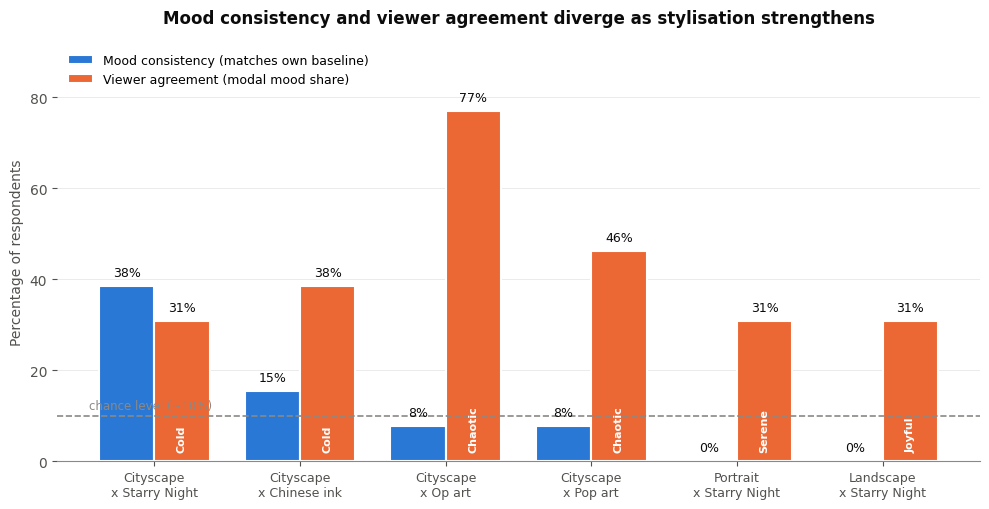

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(len(labels)); w = 0.38

b1 = ax.bar(x - w/2, consistency, w, label="Mood consistency (matches own baseline)",
            color=C1, edgecolor=SURFACE, linewidth=1.5)
b2 = ax.bar(x + w/2, agreement, w, label="Viewer agreement (modal mood share)",
            color=C2, edgecolor=SURFACE, linewidth=1.5)

for b, v in list(zip(b1, consistency)) + list(zip(b2, agreement)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f"{v:.0f}%",
            ha="center", va="bottom", fontsize=9, color=INK)
for i, m in enumerate(modal_moods):
    ax.text(x[i] + w/2, 2, m, ha="center", va="bottom", fontsize=8,
            color="white", rotation=90, fontweight="bold")

ax.axhline(10, color=MUTED, linestyle="--", linewidth=1.2)
ax.text(-0.45, 11.5, "chance level (~10%)", fontsize=8.5, color=MUTED, ha="left")

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Percentage of respondents")
ax.set_ylim(0, 92)
ax.set_title("Mood consistency and viewer agreement diverge as stylisation strengthens",
             fontsize=12, fontweight="bold", color=INK, pad=14)
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.25, linewidth=0.7); ax.set_axisbelow(True)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR + "fig_A_mood_consistency_agreement.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure B: recognisability, style presence and artefacts
These stacked bars cover all six outputs at once based on each panel.

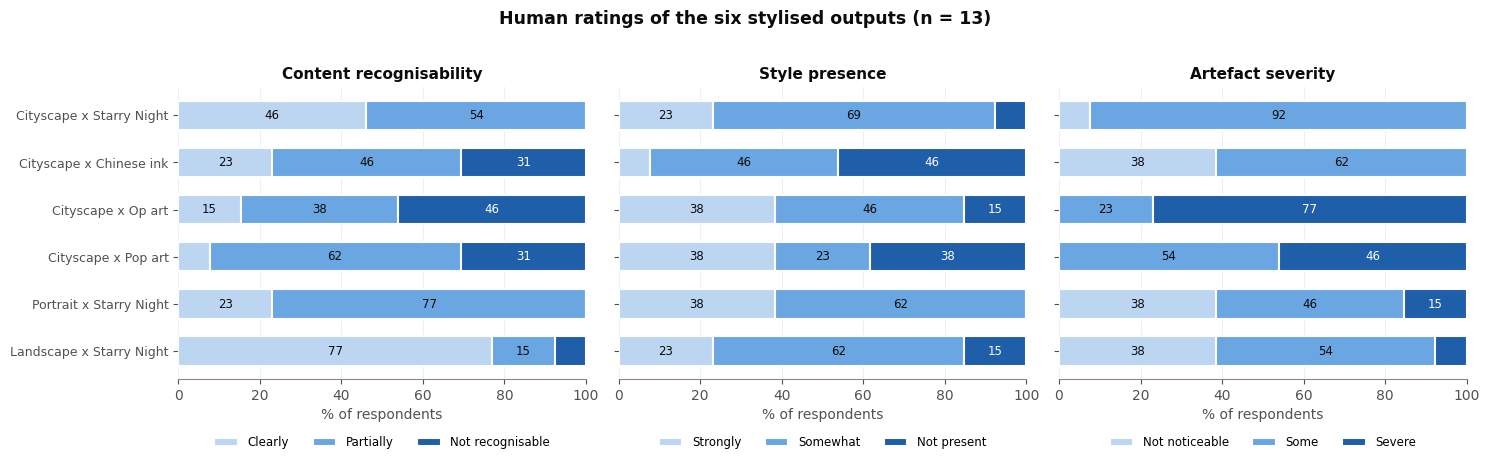

In [5]:
panels = [("Content recognisability", recog_pct, ["Clearly", "Partially", "Not recognisable"]),
          ("Style presence",          style_pct, ["Strongly", "Somewhat", "Not present"]),
          ("Artefact severity",       arte_pct,  ["Not noticeable", "Some", "Severe"])]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
ypos = np.arange(len(labels))[::-1]

for ax, (title, data, keys) in zip(axes, panels):
    data = np.array(data)
    left = np.zeros(len(labels))
    for j in range(3):
        ax.barh(ypos, data[:, j], left=left, height=0.62, color=SEQ[j],
                edgecolor=SURFACE, linewidth=1.5, label=keys[j])
        for i, v in enumerate(data[:, j]):
            if v >= 12:
                ax.text(left[i] + v/2, ypos[i], f"{v:.0f}",
                        ha="center", va="center", fontsize=8.5,
                        color="white" if j == 2 else INK)
        left += data[:, j]
    ax.set_title(title, fontsize=11, fontweight="bold", color=INK)
    ax.set_xlim(0, 100); ax.set_xlabel("% of respondents")
    ax.legend(frameon=False, fontsize=8.5, loc="upper center",
              bbox_to_anchor=(0.5, -0.16), ncol=3)
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
    ax.grid(axis="x", alpha=0.2); ax.set_axisbelow(True)

axes[0].set_yticks(ypos)
axes[0].set_yticklabels([l.replace("\n", " ") for l in labels], fontsize=9)
fig.suptitle(f"Human ratings of the six stylised outputs (n = {n})",
             fontsize=12.5, fontweight="bold", color=INK, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR + "fig_B_qualitative_ratings.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure C: SSIM against human recognisability
Checks whether a higher structural-similarity score actually corresponds to viewers finding the subject recognisable. Correlation is printed.

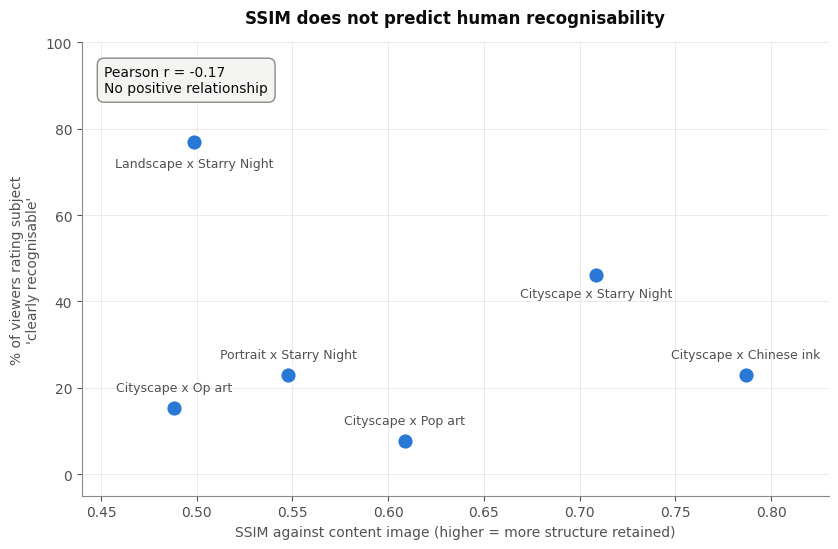

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.6))
ax.scatter(ssims, clearly_pct, s=150, color=C1, edgecolor=SURFACE, linewidth=2, zorder=3)

offsets = {0: (0, -16), 1: (0, 12), 2: (0, 12), 3: (0, 12), 4: (0, 12), 5: (0, -18)}
for i, lab in enumerate(labels):
    dx, dy = offsets[i]
    ax.annotate(lab.replace("\n", " "), (ssims[i], clearly_pct[i]),
                textcoords="offset points", xytext=(dx, dy),
                ha="center", fontsize=9, color=INK2)

r = np.corrcoef(ssims, clearly_pct)[0, 1]
ax.text(0.03, 0.95, f"Pearson r = {r:+.2f}\nNo positive relationship",
        transform=ax.transAxes, fontsize=10, va="top", color=INK,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#f4f4f2", edgecolor=MUTED))

ax.set_xlabel("SSIM against content image (higher = more structure retained)")
ax.set_ylabel("% of viewers rating subject\n'clearly recognisable'")
ax.set_title("SSIM does not predict human recognisability",
             fontsize=12, fontweight="bold", color=INK, pad=14)
ax.set_xlim(0.44, 0.83); ax.set_ylim(-5, 100)
ax.grid(alpha=0.25, linewidth=0.7); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR + "fig_C_ssim_vs_recognisability.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
print(f"{'Output':<26}{'Consist.':>9}{'Agree.':>8}  {'Modal mood':<13}{'SSIM':>7}{'Clearly rec.':>14}")
print("-" * 80)
for i, lab in enumerate(labels):
    print(f"{lab.replace(chr(10),' '):<26}{consistency[i]:>8.0f}%{agreement[i]:>7.0f}%  "
          f"{modal_moods[i]:<13}{ssims[i]:>7.4f}{clearly_pct[i]:>13.0f}%")
print("-" * 80)
r = np.corrcoef(ssims, clearly_pct)[0, 1]
print(f"Overall mood consistency: {sum(consistency)/6:.1f}%  "
      f"({int(round(sum(c*n/100 for c in consistency)))}/{n*6} paired judgements)")
print(f"Pearson r (SSIM vs clearly recognisable) = {r:+.3f}")

Output                     Consist.  Agree.  Modal mood      SSIM  Clearly rec.
--------------------------------------------------------------------------------
Cityscape x Starry Night        38%     31%  Cold          0.7086           46%
Cityscape x Chinese ink         15%     38%  Cold          0.7866           23%
Cityscape x Op art               8%     77%  Chaotic       0.4880           15%
Cityscape x Pop art              8%     46%  Chaotic       0.6087            8%
Portrait x Starry Night          0%     31%  Serene        0.5478           23%
Landscape x Starry Night         0%     31%  Joyful        0.4986           77%
--------------------------------------------------------------------------------
Overall mood consistency: 11.5%  (9/78 paired judgements)
Pearson r (SSIM vs clearly recognisable) = -0.168
